# Thyroid Disease Classification — Exploratory Data Analysis

We explore the **UCI ann-thyroid** dataset to understand which clinical/lab attributes distinguish patients with thyroid dysfunction (hyper- or hypo-thyroidism) from normal patients.

**Dataset**: 7,200 patient records (combined train+test split from UCI), 21 numeric/binary features, 1 multi-class target. We binarize: `diseased = 1 if class != 3 (normal)`.

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

%matplotlib inline

## 2. Load Data

In [2]:
df = pd.read_csv("data/thyroid.csv")
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (7200, 22)


,age,sex,on_thyroxine,query_on_thyroxine,on_antithyroid_medication,sick,pregnant,thyroid_surgery,I131_treatment,query_hypothyroid,...,goitre,tumor,hypopituitary,psych,TSH,T3,TT4,T4U,FTI,class
0,0.73,0,1,0,0,0,0,0,1,0,...,0,0,0,0,0.00060,0.015,0.120,0.082,0.146,3
1,0.24,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0.00025,0.030,0.143,0.133,0.108,3
2,0.47,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0.00190,0.024,0.102,0.131,0.078,3
3,0.64,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0.00090,0.017,0.077,0.090,0.085,3
4,0.23,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0.00025,0.026,0.139,0.090,0.153,3


Per UCI documentation, `class` encodes:
- **1** = hyperthyroidism (hyperfunction)
- **2** = hypothyroidism (subnormal)
- **3** = normal

Most clinical features are pre-normalized. Lab measurements (TSH, T3, TT4, T4U, FTI) are scaled to roughly 0–1.

## 3. Dataset Overview

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7200 entries, 0 to 7199
Data columns (total 22 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   age                        7200 non-null   float64
 1   sex                        7200 non-null   int64  
 2   on_thyroxine               7200 non-null   int64  
 3   query_on_thyroxine         7200 non-null   int64  
 4   on_antithyroid_medication  7200 non-null   int64  
 5   sick                       7200 non-null   int64  
 6   pregnant                   7200 non-null   int64  
 7   thyroid_surgery            7200 non-null   int64  
 8   I131_treatment             7200 non-null   int64  
 9   query_hypothyroid          7200 non-null   int64  
 10  query_hyperthyroid         7200 non-null   int64  
 11  lithium                    7200 non-null   int64  
 12  goitre                     7200 non-null   int64  
 13  tumor                      7200 non-null   int64

In [4]:
df.describe().round(3)

,age,sex,on_thyroxine,query_on_thyroxine,on_antithyroid_medication,sick,pregnant,thyroid_surgery,I131_treatment,query_hypothyroid,...,goitre,tumor,hypopituitary,psych,TSH,T3,TT4,T4U,FTI,class
count,7200.000,7200.000,7200.000,7200.000,7200.000,7200.000,7200.000,7200.000,7200.000,7200.000,...,7200.000,7200.000,7200.000,7200.000,7200.000,7200.000,7200.000,7200.000,7200.000,7200.000
mean,0.521,0.304,0.131,0.015,0.013,0.038,0.011,0.014,0.017,0.066,...,0.008,0.026,0.000,0.049,0.005,0.020,0.109,0.098,0.113,2.903
std,0.189,0.460,0.337,0.123,0.112,0.192,0.104,0.118,0.129,0.248,...,0.090,0.158,0.012,0.216,0.023,0.008,0.036,0.019,0.036,0.366
min,0.010,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,...,0.000,0.000,0.000,0.000,0.000,0.000,0.002,0.017,0.002,1.000
25%,0.370,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,...,0.000,0.000,0.000,0.000,0.001,0.017,0.089,0.087,0.095,3.000
50%,0.550,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,...,0.000,0.000,0.000,0.000,0.002,0.020,0.107,0.097,0.111,3.000
75%,0.670,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,...,0.000,0.000,0.000,0.000,0.003,0.022,0.125,0.104,0.127,3.000
max,0.970,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,...,1.000,1.000,1.000,1.000,0.530,0.180,0.600,0.233,0.642,3.000


In [5]:
print(f"Duplicate rows: {df.duplicated().sum()}")
print(f"\nClass counts:")
for c in sorted(df['class'].unique()):
    n = (df['class'] == c).sum()
    print(f"  class {c}: {n:5d} ({n/len(df)*100:.1f}%)")

Duplicate rows: 71

Class counts:
  class 1:   166 (2.3%)
  class 2:   368 (5.1%)
  class 3:  6666 (92.6%)


## 4. Missing / Invalid Values

In [6]:
print(f"Total missing values: {df.isnull().sum().sum()}")
print(f"Constant columns    : {[c for c in df.columns if df[c].nunique() == 1]}")

Total missing values: 0
Constant columns    : []


## 5. Target Variable Distribution

/var/folders/3t/st_qgzrd3957m1htwzrz0pkc0000gn/T/ipykernel_25358/2468202961.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="class", data=df, palette="Set2", ax=axes[0], order=[1,2,3])
/var/folders/3t/st_qgzrd3957m1htwzrz0pkc0000gn/T/ipykernel_25358/2468202961.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(["Hyper (1)", "Hypo (2)", "Normal (3)"])
/var/folders/3t/st_qgzrd3957m1htwzrz0pkc0000gn/T/ipykernel_25358/2468202961.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="diseased", data=df, palette="Set2", ax=axes[1], order=[0,1])
/var/folders/3t/st_qgzrd3957m1htw

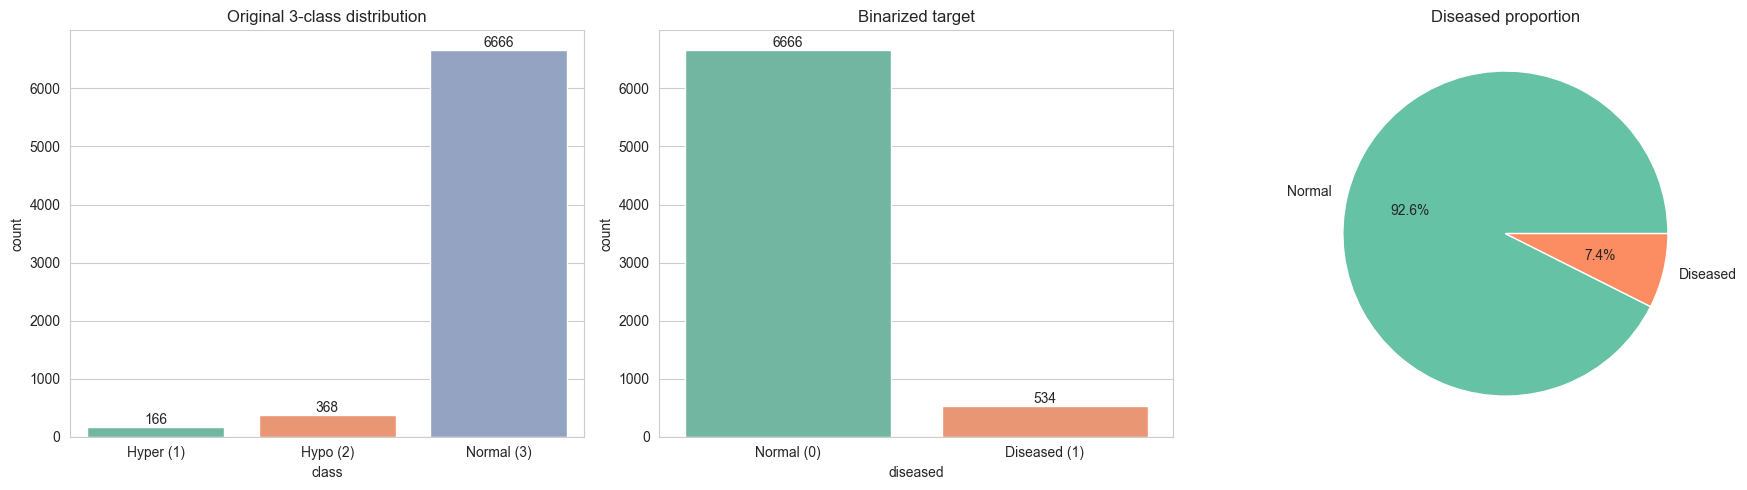

Diseased rate: 7.42%


In [7]:
df["diseased"] = (df["class"] != 3).astype(int)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.countplot(x="class", data=df, palette="Set2", ax=axes[0], order=[1,2,3])
axes[0].set_xticklabels(["Hyper (1)", "Hypo (2)", "Normal (3)"])
axes[0].set_title("Original 3-class distribution")
for p in axes[0].patches:
    axes[0].annotate(f"{int(p.get_height())}",
                     (p.get_x()+p.get_width()/2., p.get_height()),
                     ha="center", va="bottom", fontsize=10)

sns.countplot(x="diseased", data=df, palette="Set2", ax=axes[1], order=[0,1])
axes[1].set_xticklabels(["Normal (0)", "Diseased (1)"])
axes[1].set_title("Binarized target")
for p in axes[1].patches:
    axes[1].annotate(f"{int(p.get_height())}",
                     (p.get_x()+p.get_width()/2., p.get_height()),
                     ha="center", va="bottom", fontsize=10)

df["diseased"].value_counts().plot.pie(
    labels=["Normal","Diseased"], autopct="%1.1f%%",
    colors=["#66c2a5","#fc8d62"], ax=axes[2])
axes[2].set_ylabel(""); axes[2].set_title("Diseased proportion")
plt.tight_layout(); plt.show()
print(f"Diseased rate: {df['diseased'].mean()*100:.2f}%")

## 6. Univariate — Lab Measurements

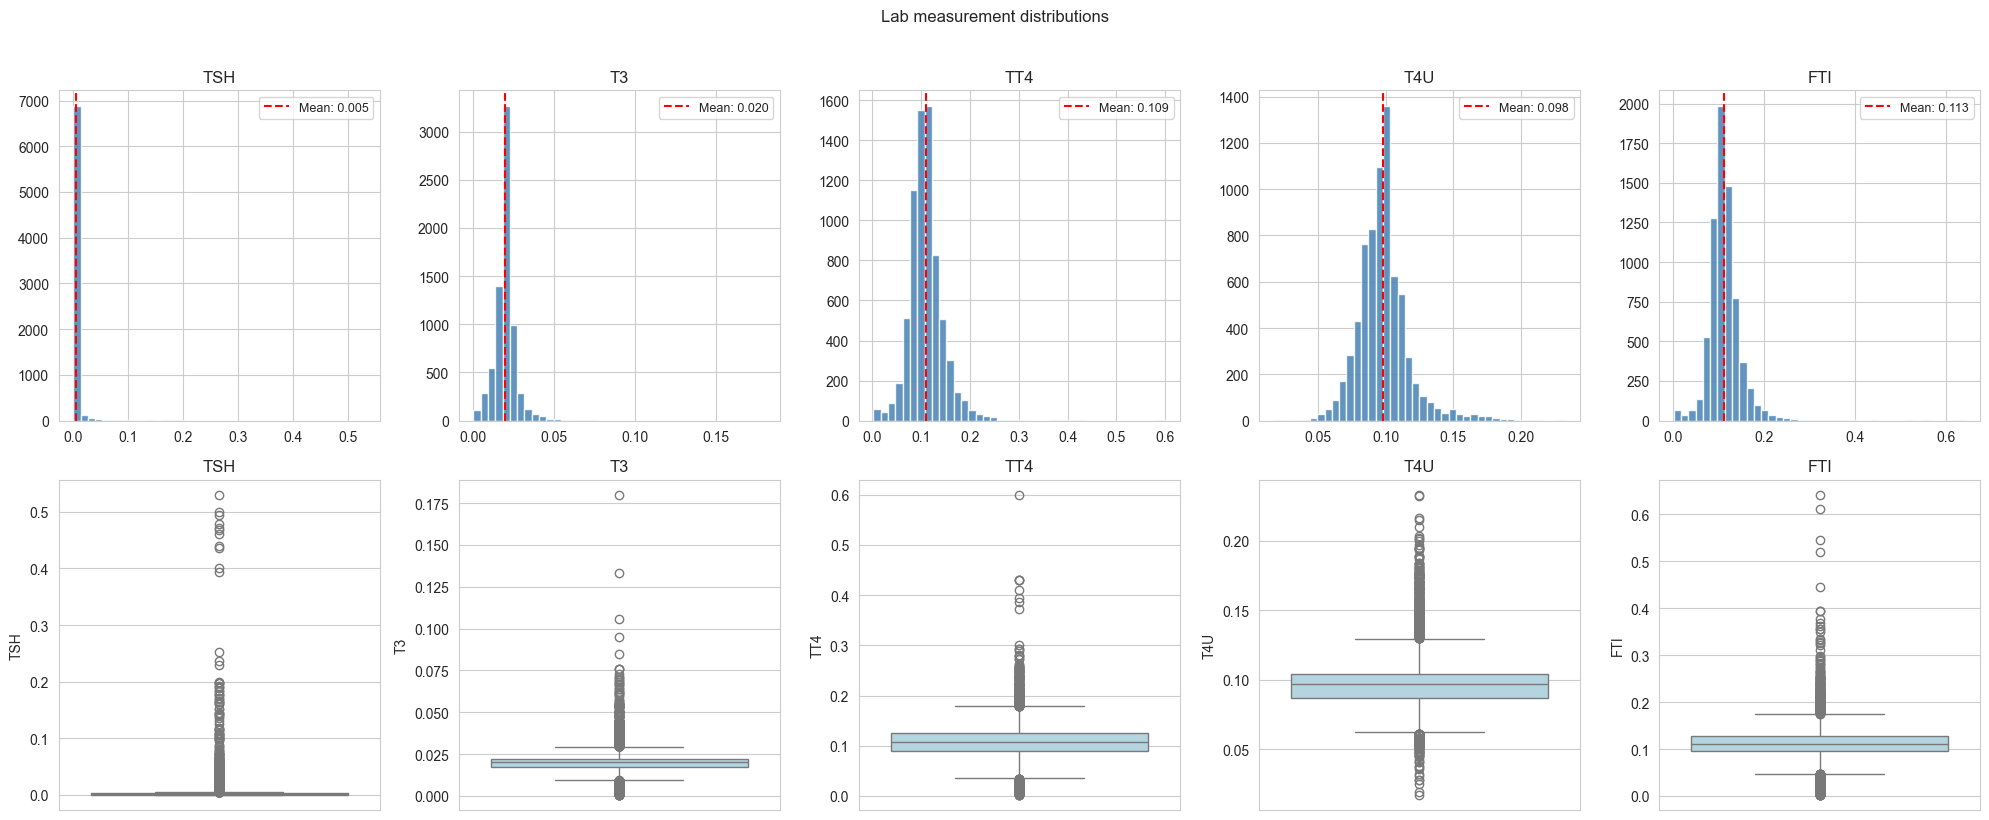

In [8]:
lab = ["TSH","T3","TT4","T4U","FTI"]
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
for i, col in enumerate(lab):
    df[col].hist(bins=40, color="steelblue", edgecolor="white", alpha=0.85, ax=axes[0,i])
    axes[0,i].axvline(df[col].mean(), color="red", linestyle="--",
                      label=f"Mean: {df[col].mean():.3f}")
    axes[0,i].set_title(col); axes[0,i].legend(fontsize=9)
    sns.boxplot(y=df[col], ax=axes[1,i], color="lightblue")
    axes[1,i].set_title(col)
plt.suptitle("Lab measurement distributions", y=1.02)
plt.tight_layout(); plt.show()

## 7. Univariate — Binary Clinical Flags

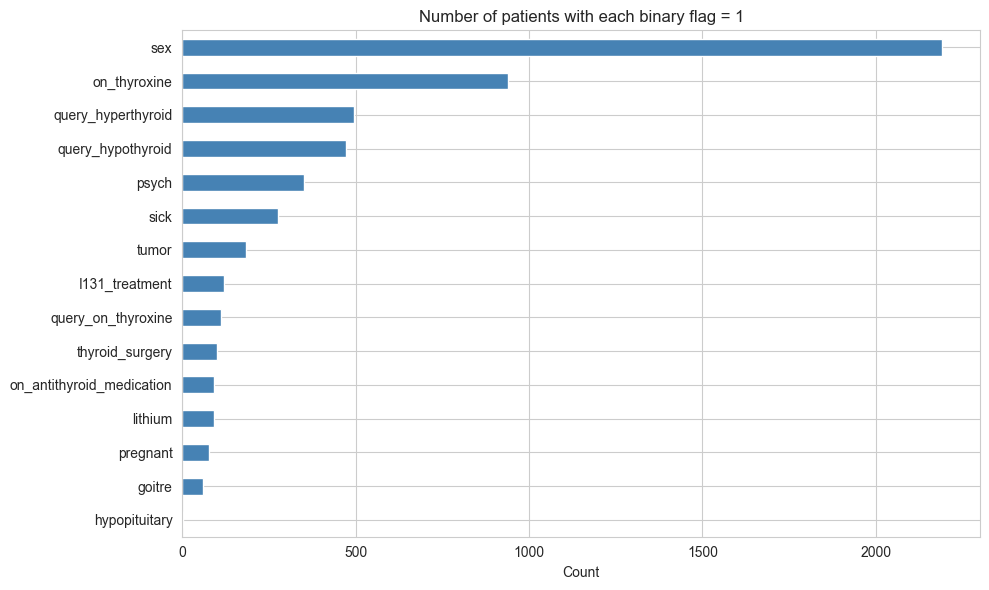

{'hypopituitary': 1, 'goitre': 59, 'pregnant': 78, 'lithium': 91, 'on_antithyroid_medication': 92, 'thyroid_surgery': 101, 'query_on_thyroxine': 111, 'I131_treatment': 121, 'tumor': 184, 'sick': 276, 'psych': 352, 'query_hypothyroid': 472, 'query_hyperthyroid': 495, 'on_thyroxine': 940, 'sex': 2191}


In [9]:
flags = ["sex","on_thyroxine","query_on_thyroxine","on_antithyroid_medication",
         "sick","pregnant","thyroid_surgery","I131_treatment","query_hypothyroid",
         "query_hyperthyroid","lithium","goitre","tumor","hypopituitary","psych"]
counts = df[flags].sum().sort_values(ascending=True)
plt.figure(figsize=(10, 6))
counts.plot(kind="barh", color="steelblue")
plt.title("Number of patients with each binary flag = 1")
plt.xlabel("Count")
plt.tight_layout(); plt.show()
print(counts.to_dict())

## 8. Bivariate — Lab Measurements vs Diseased

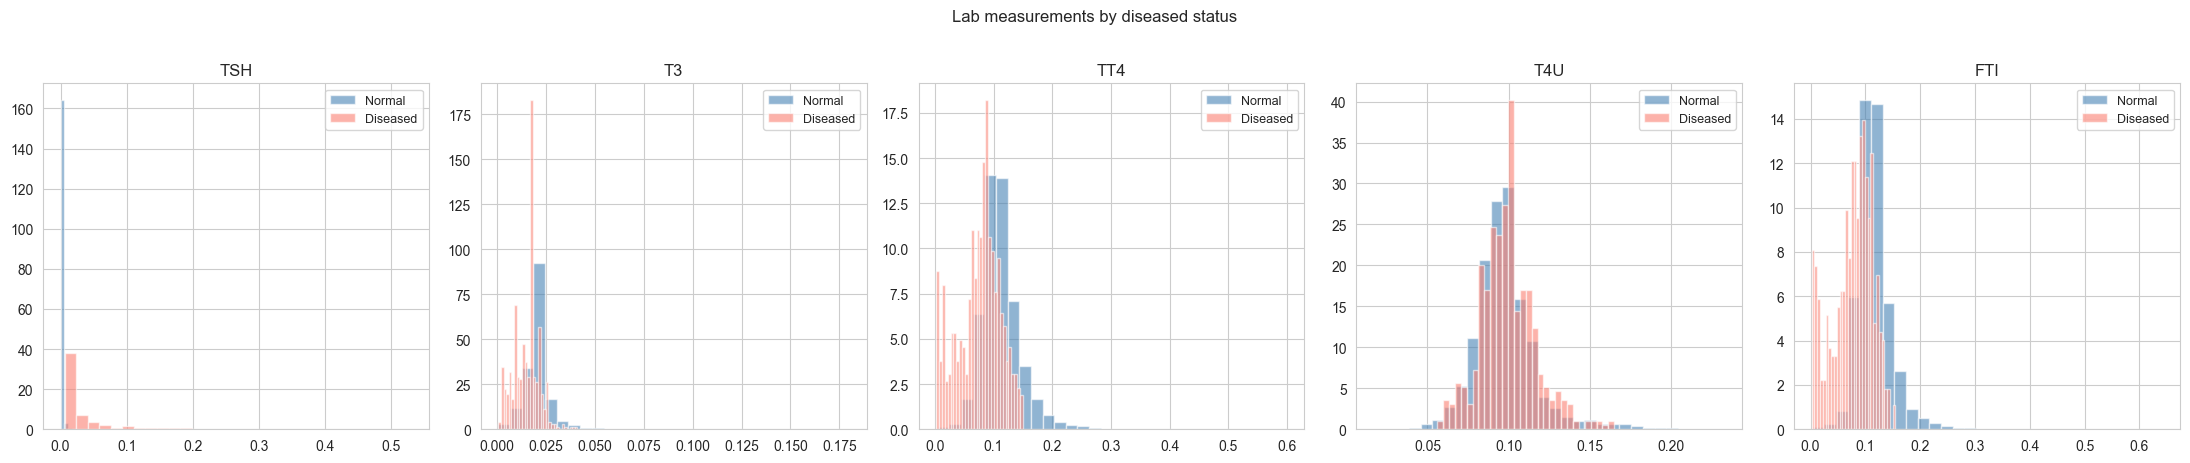

In [10]:
fig, axes = plt.subplots(1, 5, figsize=(22, 4.5))
for i, col in enumerate(lab):
    for d, color, label in [(0, "steelblue", "Normal"), (1, "salmon", "Diseased")]:
        sub = df[df["diseased"]==d][col]
        axes[i].hist(sub, bins=30, alpha=0.6, color=color, label=label, density=True)
    axes[i].set_title(col); axes[i].legend(fontsize=9)
plt.suptitle("Lab measurements by diseased status", y=1.02)
plt.tight_layout(); plt.show()

In [11]:
# Means by diseased status
comparison = df.groupby("diseased")[lab].mean().T
comparison.columns = ["Normal","Diseased"]
comparison["Difference"] = comparison["Diseased"] - comparison["Normal"]
comparison.round(4)

,Normal,Diseased,Difference
TSH,0.0021,0.0394,0.0373
T3,0.0204,0.0149,-0.0055
TT4,0.1122,0.0749,-0.0373
T4U,0.0977,0.0995,0.0018
FTI,0.1161,0.0768,-0.0393


In [12]:
# Means split by all 3 classes
split3 = df.groupby("class")[lab].mean().T
split3.columns = ["Hyper","Hypo","Normal"]
split3.round(4)

,Hyper,Hypo,Normal
TSH,0.0963,0.0137,0.0021
T3,0.0097,0.0173,0.0204
TT4,0.0326,0.0940,0.1122
T4U,0.1032,0.0978,0.0977
FTI,0.0323,0.0969,0.1161


## 9. Bivariate — Disease Rate by Clinical Flag

In [13]:
rates = pd.DataFrame({
    "flag=1 disease rate": [df[df[c]==1]["diseased"].mean()*100 for c in flags],
    "flag=0 disease rate": [df[df[c]==0]["diseased"].mean()*100 for c in flags],
    "flag=1 count":       [df[c].sum() for c in flags],
}, index=flags).sort_values("flag=1 disease rate", ascending=False)
rates.round(1)

,flag=1 disease rate,flag=0 disease rate,flag=1 count
query_hypothyroid,15.9,6.8,472
I131_treatment,9.9,7.4,121
lithium,6.6,7.4,91
tumor,6.5,7.4,184
query_hyperthyroid,6.5,7.5,495
sick,6.2,7.5,276
sex,5.2,8.4,2191
query_on_thyroxine,4.5,7.5,111
on_antithyroid_medication,4.3,7.5,92
thyroid_surgery,4.0,7.5,101


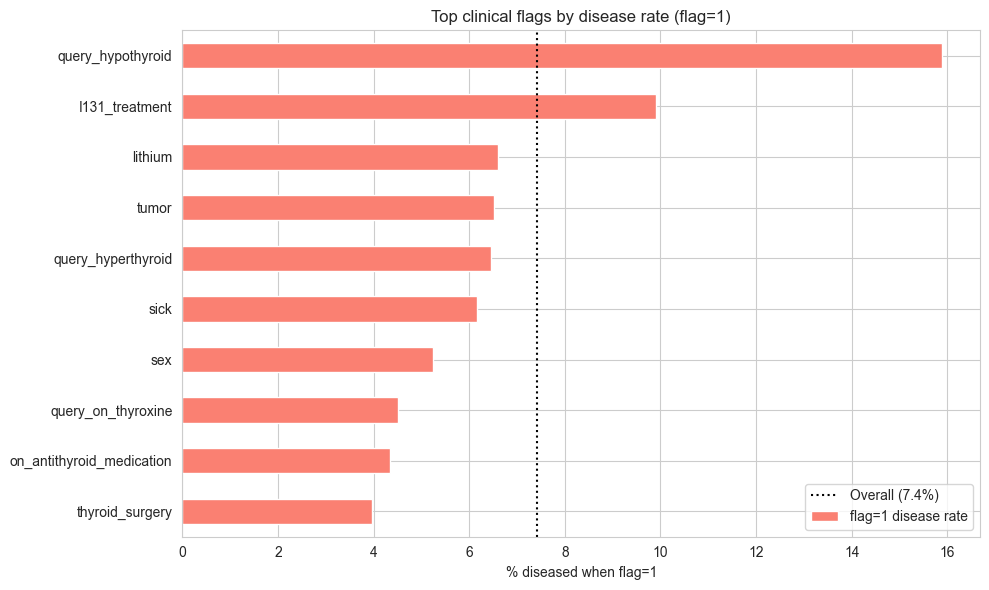

In [14]:
fig, ax = plt.subplots(figsize=(10, 6))
rates_plot = rates.head(10)["flag=1 disease rate"].sort_values()
rates_plot.plot(kind="barh", color="salmon", ax=ax)
ax.axvline(df["diseased"].mean()*100, color="black", linestyle=":",
           label=f"Overall ({df['diseased'].mean()*100:.1f}%)")
ax.set_xlabel("% diseased when flag=1")
ax.set_title("Top clinical flags by disease rate (flag=1)")
ax.legend()
plt.tight_layout(); plt.show()

## 10. Correlation Analysis

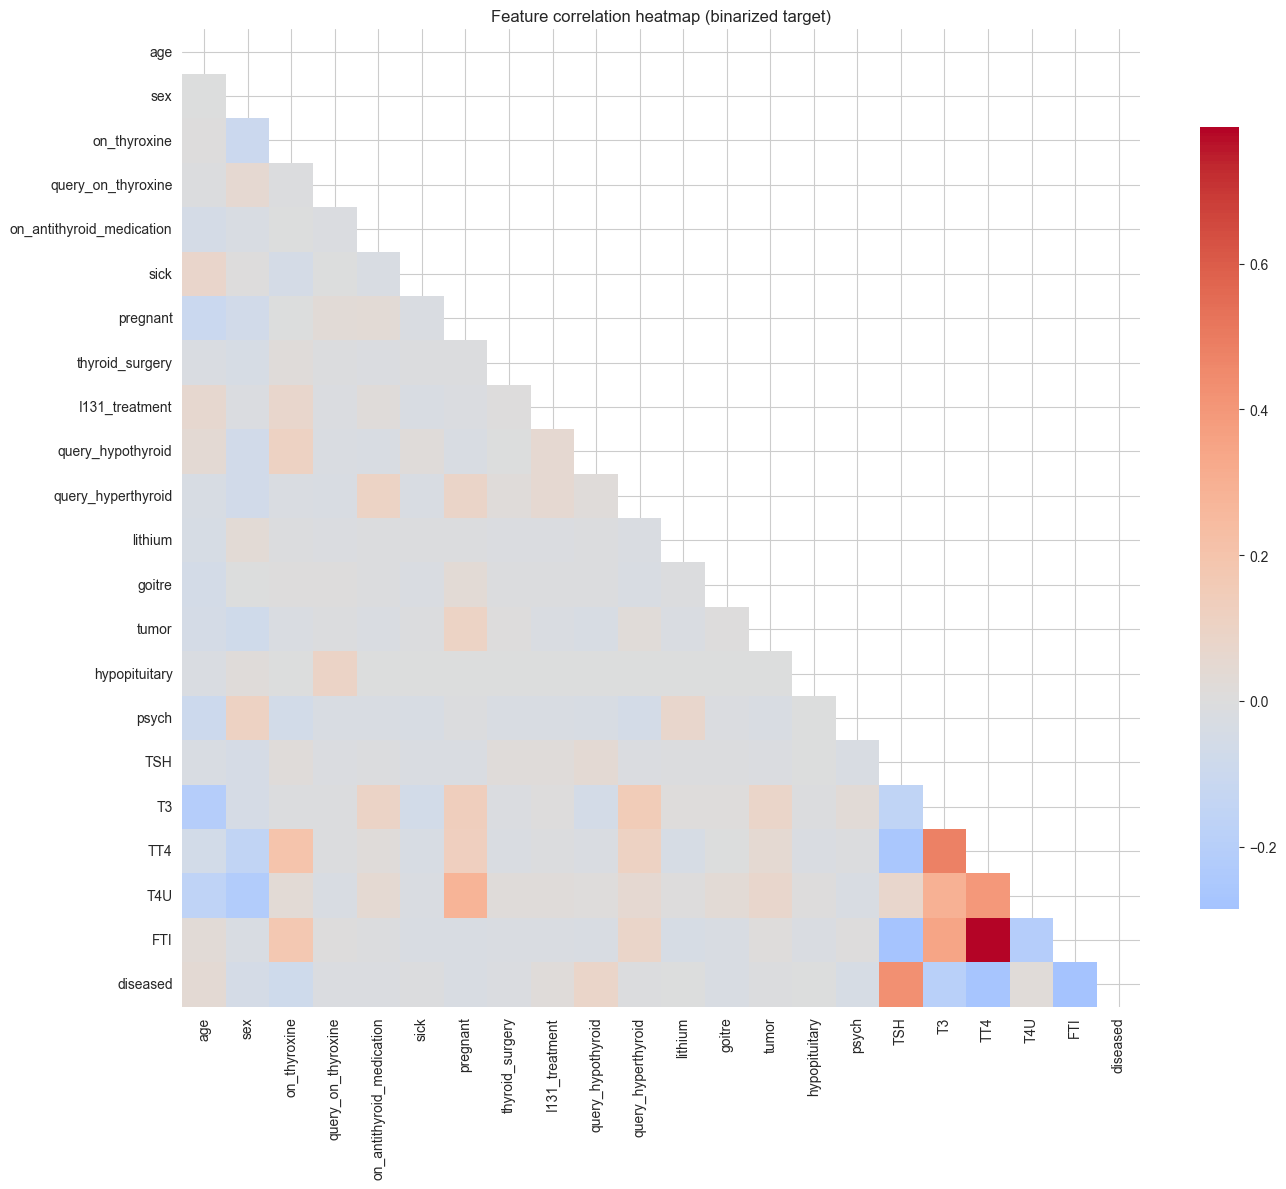

In [15]:
plt.figure(figsize=(14, 12))
corr = df.drop(columns=["class"]).corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap="coolwarm", center=0, square=False,
            cbar_kws={"shrink": 0.8})
plt.title("Feature correlation heatmap (binarized target)")
plt.tight_layout(); plt.show()

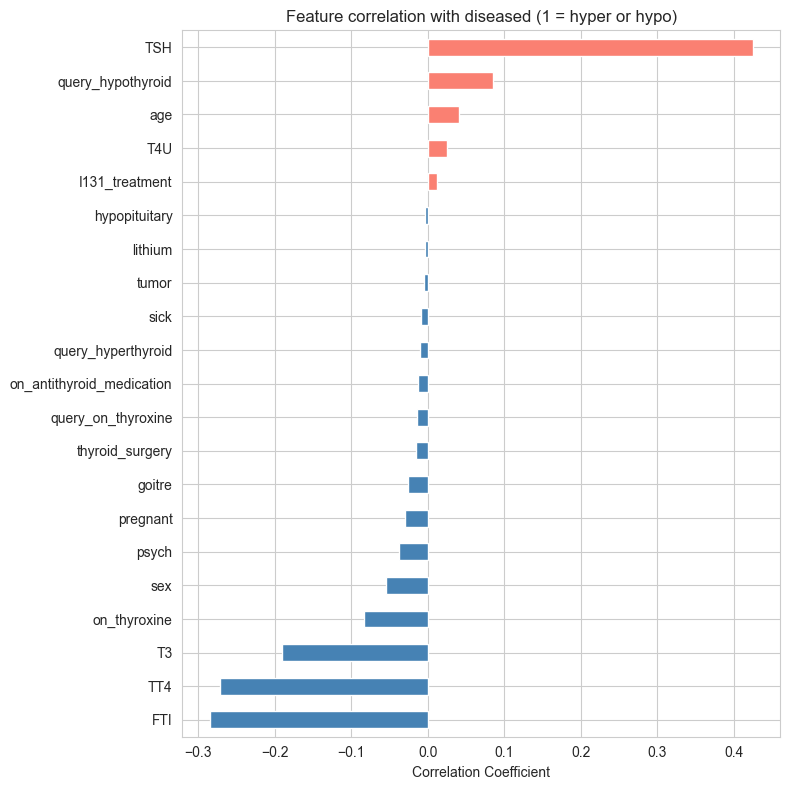

Top 10 features by absolute correlation with diseased:
TSH                  0.425
FTI                  0.286
TT4                  0.271
T3                   0.191
query_hypothyroid    0.086
on_thyroxine         0.083
sex                  0.055
age                  0.041
psych                0.037
pregnant             0.030
Name: diseased, dtype: float64


In [16]:
target_corr = df.drop(columns=["class"]).corr()["diseased"].drop("diseased").sort_values(ascending=False)
plt.figure(figsize=(8, 8))
target_corr.plot(kind="barh",
                 color=["salmon" if x > 0 else "steelblue" for x in target_corr])
plt.title("Feature correlation with diseased (1 = hyper or hypo)")
plt.xlabel("Correlation Coefficient"); plt.gca().invert_yaxis()
plt.tight_layout(); plt.show()
print("Top 10 features by absolute correlation with diseased:")
print(target_corr.abs().sort_values(ascending=False).head(10).round(3))

## 11. Pair Plot — Lab Measurements

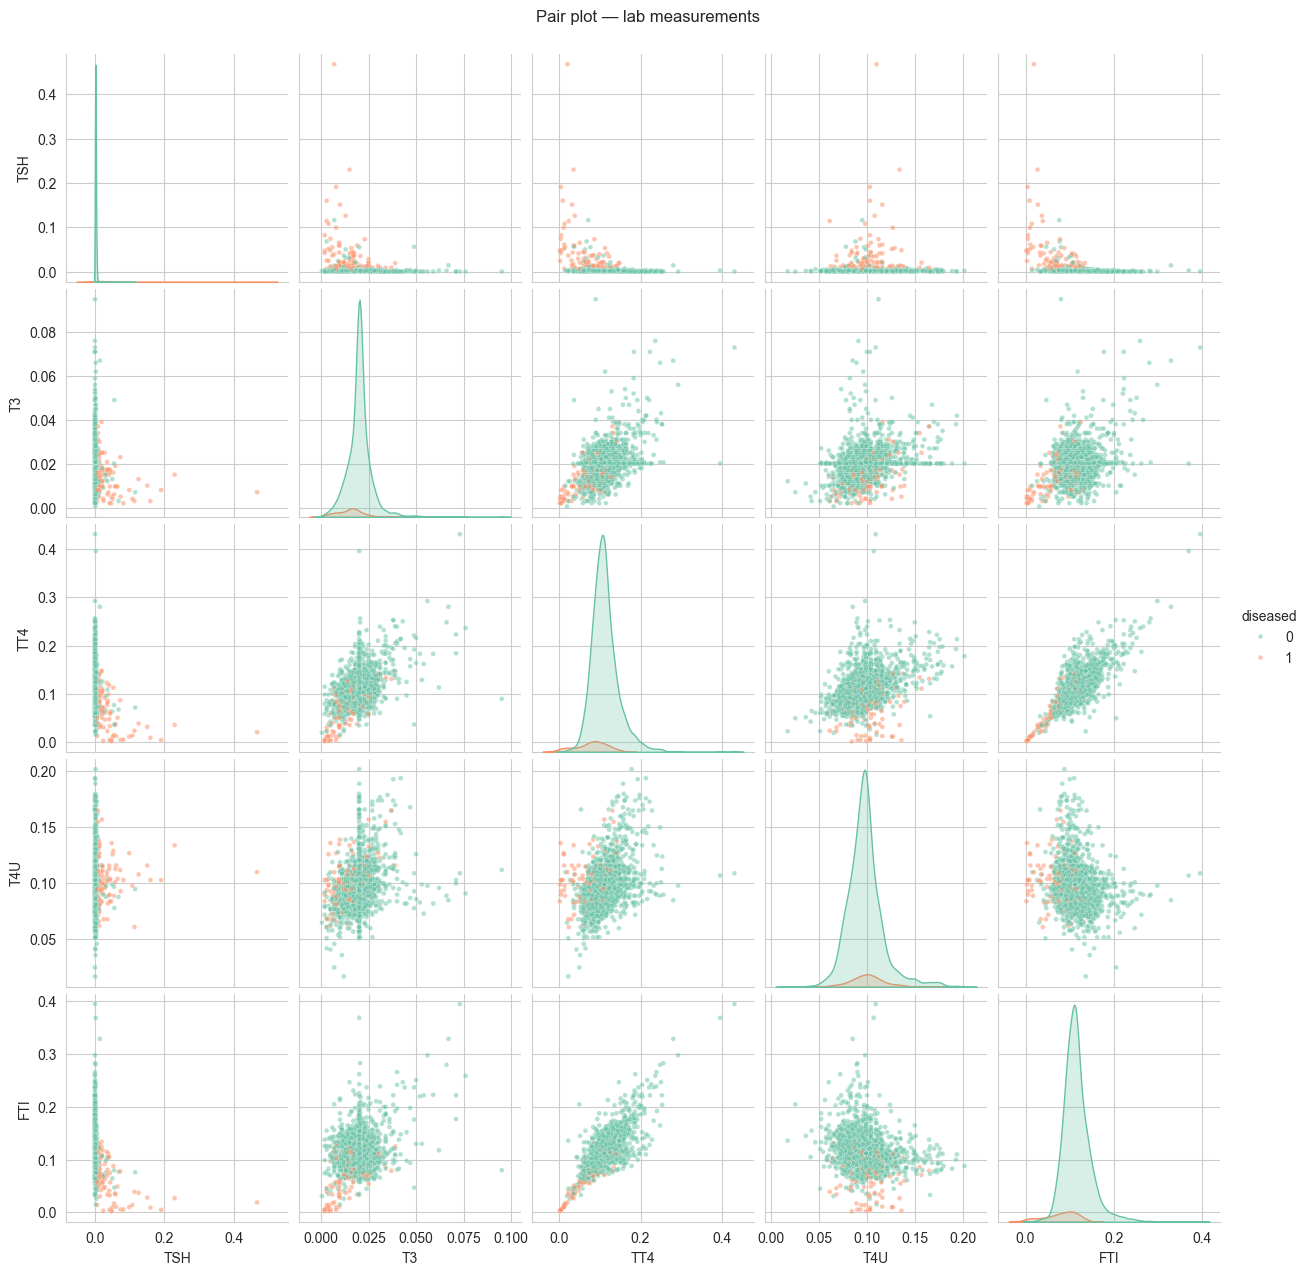

In [17]:
sample = df.sample(n=min(2000, len(df)), random_state=42)
sns.pairplot(sample[lab + ["diseased"]], hue="diseased", palette="Set2",
             diag_kind="kde", plot_kws={"alpha": 0.5, "s": 12})
plt.suptitle("Pair plot — lab measurements", y=1.02)
plt.show()

## 12. Key EDA Findings

| # | Finding |
|---|--------|
| 1 | **Heavy class imbalance**: ~92.6% normal vs only ~7.4% diseased — F1 / recall on the positive class are the right metrics |
| 2 | **TSH is the dominant predictor** — patients with elevated TSH are almost always hypothyroid; TSH alone separates a large fraction of cases |
| 3 | **`on_thyroxine` flag has a huge prior** — 97% of patients on thyroxine are flagged "diseased" because they're already being treated |
| 4 | **Hyper- and hypo-thyroidism are opposite directions on T3/T4**: hypo patients have low T3/T4 and high TSH; hyper patients have the reverse |
| 5 | **No missing values** — UCI's ann-thyroid is already cleaned and pre-normalized |
| 6 | **Constant columns** (where `nunique() == 1`) should be dropped before modeling — none in this clean release, but worth checking |
| 7 | **The dataset is famously "easy" if you exploit treatment flags** — beware leakage; a model that simply learns "on_thyroxine -> diseased" reaches high accuracy without learning thyroid biochemistry |